<a href="https://colab.research.google.com/github/jonitodev/PembelajaranMesin/blob/main/JS04/JS04_01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# JS04 — Lab 1 dan Lab 2

Data: `dataset.csv` untuk Lab 1 dan `Posisi_gaji.csv` untuk Lab 2. Unggah keduanya ke Files di Colab, lalu jalankan semua sel.

[Jobsheet Lab 1](https://polinema.gitbook.io/jti-modul-praktikum-pembelajaran-mesin-mah/js04-regresi/lab-1) · [Jobsheet Lab 2](https://polinema.gitbook.io/jti-modul-praktikum-pembelajaran-mesin-mah/js04-regresi/lab-2)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from pathlib import Path
from IPython.display import display
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

sns.set_theme(style='whitegrid')
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
DATA_DIR = Path('/content') if Path('/content').is_dir() else Path('.')

def evaluasi(aktual, prediksi):
    mse = mean_squared_error(aktual, prediksi)
    return {'R2': r2_score(aktual, prediksi), 'MSE': mse,
            'MAE': mean_absolute_error(aktual, prediksi), 'RMSE': np.sqrt(mse)}

## Lab 1 — Regresi linier sederhana
Lama keanggotaan digunakan untuk memprediksi pengeluaran tahunan pelanggan.

In [2]:
ecommerce = pd.read_csv(DATA_DIR / 'dataset.csv')
display(ecommerce.head())
print('Ukuran data:', ecommerce.shape)
ecommerce.info()
display(ecommerce.describe())

,Email,Address,Avatar,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
0,mstephenson@fernandez.com,"835 Frank Tunnel\r\nWrightmouth, MI 82180-9605",Violet,34.4973,12.6557,39.5777,4.0826,587.9511
1,hduke@hotmail.com,"4547 Archer Common\r\nDiazchester, CA 06566-8576",DarkGreen,31.9263,11.1095,37.2690,2.6640,392.2049
2,pallen@yahoo.com,"24645 Valerie Unions Suite 582\r\nCobbborough,...",Bisque,33.0009,11.3303,37.1106,4.1045,487.5475
3,riverarebecca@gmail.com,"1414 David Throughway\r\nPort Jason, OH 22070-...",SaddleBrown,34.3056,13.7175,36.7213,3.1202,581.8523
4,mstephens@davidson-herman.com,"14023 Rodriguez Passage\r\nPort Jacobville, PR...",MediumAquaMarine,33.3307,12.7952,37.5367,4.4463,599.4061


Ukuran data: (500, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Email                 500 non-null    object 
 1   Address               500 non-null    object 
 2   Avatar                500 non-null    object 
 3   Avg. Session Length   500 non-null    float64
 4   Time on App           500 non-null    float64
 5   Time on Website       500 non-null    float64
 6   Length of Membership  500 non-null    float64
 7   Yearly Amount Spent   500 non-null    float64
dtypes: float64(5), object(3)
memory usage: 31.4+ KB


,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
count,500.0000,500.0000,500.0000,500.0000,500.0000
mean,33.0532,12.0525,37.0604,3.5335,499.3140
std,0.9926,0.9942,1.0105,0.9993,79.3148
min,29.5324,8.5082,33.9138,0.2699,256.6706
25%,32.3418,11.3882,36.3493,2.9304,445.0383
50%,33.0820,11.9832,37.0694,3.5340,498.8879
75%,33.7120,12.7538,37.7164,4.1265,549.3138
max,36.1397,15.1270,40.0052,6.9227,765.5185


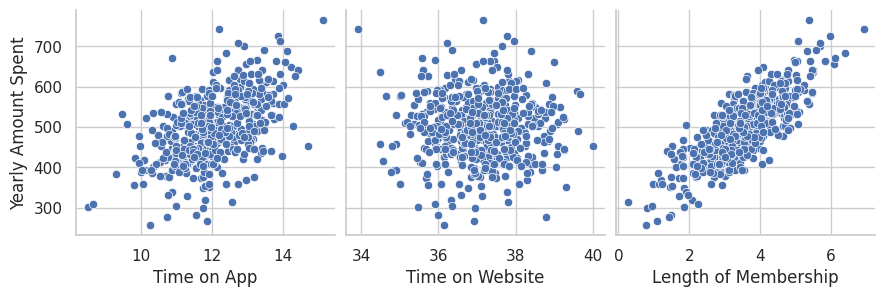

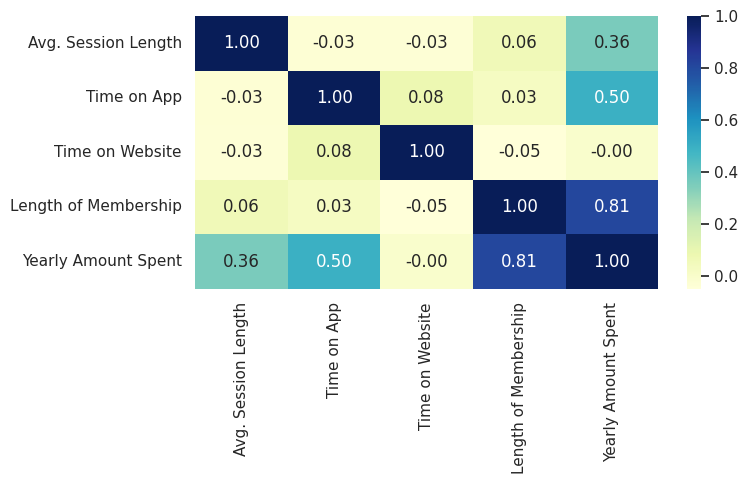

In [3]:
sns.pairplot(ecommerce,
             x_vars=['Time on App', 'Time on Website', 'Length of Membership'],
             y_vars=['Yearly Amount Spent'], height=3)
plt.show()

plt.figure(figsize=(8, 5))
sns.heatmap(ecommerce.select_dtypes('number').corr(), annot=True, fmt='.2f', cmap='YlGnBu')
plt.tight_layout()
plt.show()

In [4]:
X_ec = ecommerce[['Length of Membership']]
y_ec = ecommerce['Yearly Amount Spent']
X_ec_train, X_ec_test, y_ec_train, y_ec_test = train_test_split(
    X_ec, y_ec, test_size=0.3, random_state=100)

model_ec = sm.OLS(y_ec_train, sm.add_constant(X_ec_train)).fit()
pred_ec_train = model_ec.predict(sm.add_constant(X_ec_train))
pred_ec_test = model_ec.predict(sm.add_constant(X_ec_test))
print('Koefisien model:')
display(model_ec.params)
display(pd.DataFrame({'Train': evaluasi(y_ec_train, pred_ec_train),
                      'Test': evaluasi(y_ec_test, pred_ec_test)}).T)

Koefisien model:


,0
const,265.2483
Length of Membership,66.3015


,R2,MSE,MAE,RMSE
Train,0.6688,"2,173.3747",37.8638,46.6195
Test,0.6119,"2,171.3702",36.8673,46.5980


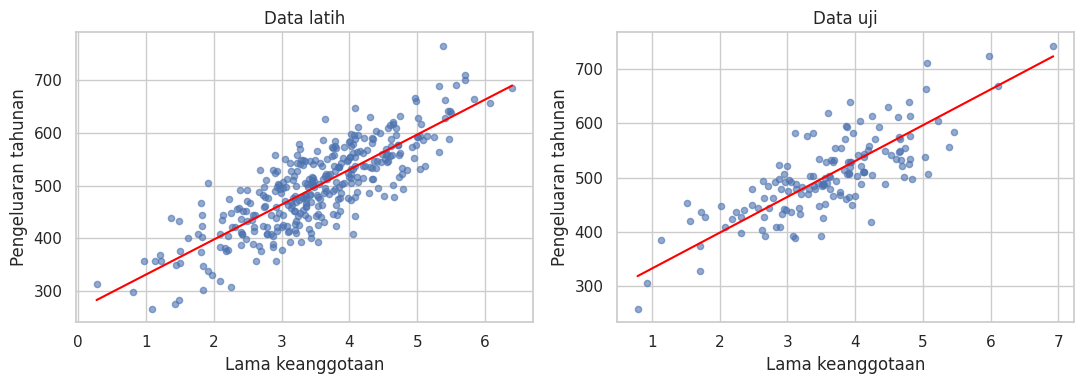

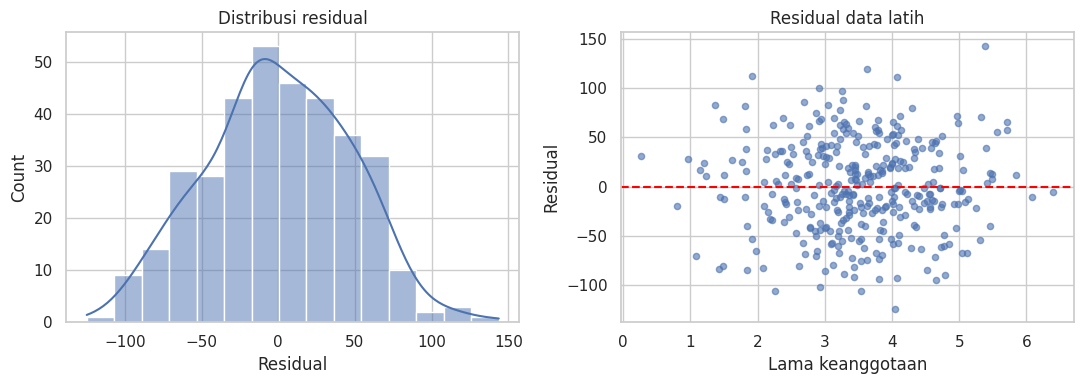

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, X, y, pred, judul in [
    (axes[0], X_ec_train, y_ec_train, pred_ec_train, 'Data latih'),
    (axes[1], X_ec_test, y_ec_test, pred_ec_test, 'Data uji')]:
    urut = np.argsort(X.iloc[:, 0].to_numpy())
    ax.scatter(X.iloc[:, 0], y, alpha=0.6, s=20)
    ax.plot(X.iloc[urut, 0], np.asarray(pred)[urut], color='red')
    ax.set(title=judul, xlabel='Lama keanggotaan', ylabel='Pengeluaran tahunan')
plt.tight_layout()
plt.show()

residual = y_ec_train - pred_ec_train
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.histplot(residual, bins=15, kde=True, ax=axes[0])
axes[0].set(title='Distribusi residual', xlabel='Residual')
axes[1].scatter(X_ec_train.iloc[:, 0], residual, alpha=0.6, s=20)
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set(title='Residual data latih', xlabel='Lama keanggotaan', ylabel='Residual')
plt.tight_layout()
plt.show()

R² data uji sebesar 0,6119 dengan RMSE 46,60. Lama keanggotaan berkaitan positif dengan pengeluaran, tetapi masih ada variasi yang belum dijelaskan model.

## Lab 2 — SVR
Level posisi dan gaji distandarkan sebelum model dilatih.

In [6]:
gaji = pd.read_csv(DATA_DIR / 'Posisi_gaji.csv')
display(gaji)

,Posisi,Level,Gaji
0,Business Analyst,1,45000
1,Junior Consultant,2,50000
2,Senior Consultant,3,60000
3,Manager,4,80000
4,Country Manager,5,110000
5,Region Manager,6,150000
6,Partner,7,200000
7,Senior Partner,8,300000
8,C-level,9,500000
9,CEO,10,1000000


In [7]:
X_gaji = gaji[['Level']].to_numpy()
y_gaji = gaji['Gaji'].to_numpy()
sc_X, sc_y = StandardScaler(), StandardScaler()
X_gaji_scaled = sc_X.fit_transform(X_gaji)
y_gaji_scaled = sc_y.fit_transform(y_gaji.reshape(-1, 1)).ravel()

svr_gaji = SVR(kernel='rbf').fit(X_gaji_scaled, y_gaji_scaled)
pred_level = svr_gaji.predict(sc_X.transform([[6.5]]))
pred_gaji = sc_y.inverse_transform(pred_level.reshape(-1, 1))[0, 0]
print(f'Prediksi gaji level 6.5: {pred_gaji:,.2f}')

pred_scaled = svr_gaji.predict(X_gaji_scaled)
pred_asli = sc_y.inverse_transform(pred_scaled.reshape(-1, 1)).ravel()
display(pd.DataFrame({'Train (standar)': evaluasi(y_gaji_scaled, pred_scaled),
                      'Train (gaji asli)': evaluasi(y_gaji, pred_asli)}).T)

Prediksi gaji level 6.5: 170,370.02


,R2,MSE,MAE,RMSE
Train (standar),0.7516,0.2484,0.2230,0.4984
Train (gaji asli),0.7516,"20,036,494,264.1318","63,332.3921","141,550.3241"


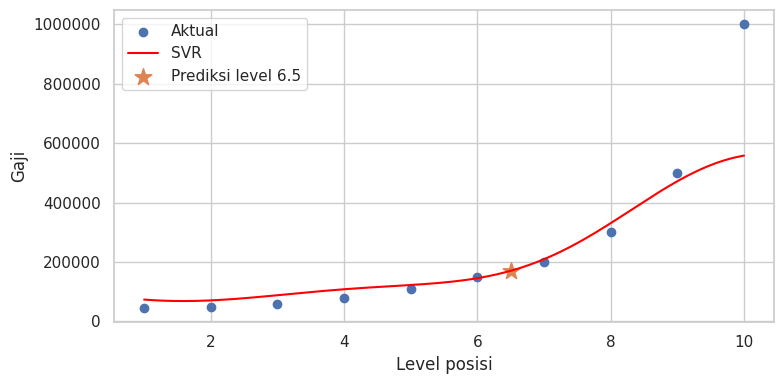

In [8]:
grid = np.linspace(1, 10, 300).reshape(-1, 1)
kurva = sc_y.inverse_transform(svr_gaji.predict(sc_X.transform(grid)).reshape(-1, 1))
plt.figure(figsize=(8, 4))
plt.scatter(X_gaji, y_gaji, label='Aktual')
plt.plot(grid, kurva, color='red', label='SVR')
plt.scatter([6.5], [pred_gaji], marker='*', s=160, label='Prediksi level 6.5')
plt.xlabel('Level posisi')
plt.ylabel('Gaji')
plt.ticklabel_format(axis='y', style='plain')
plt.legend()
plt.tight_layout()
plt.show()

Prediksi gaji level 6,5 adalah 170.370,02. R² sebesar 0,7516 dihitung pada data latih, sehingga belum menunjukkan performa pada data baru.